In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from pathlib import Path
import cv2
import numpy as np
import tifffile as tiff
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Model planning:
1. Plain CNN 1 ()
2. Deeper + Higher receptive field
3. Resnet18 encoder -> U-Net/FPN

# Loss:

In [ ]:
class HeatmapCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=2, dilation=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.head = nn.Sequential(
            nn.Conv2d(256, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 2, 1)  # logits: channel 0=interior, channel 1=edge
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.head(x)
        return x


# Instantiate model
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HeatmapCNN().to(DEVICE)
print(f'Model on device: {DEVICE}')
print(model)

Model on device: cuda
HeatmapCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
    (1): ReLU(inplace=True)
  )
  (head): Sequential(
    (0): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
    (3): Tanh()
  )
)


In [ ]:
# 2-channel segmentation setup: channel 0=interior, channel 1=edge
criterion = nn.BCEWithLogitsLoss(reduction='none')

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


def total_variation_loss(x):
    """Small smoothness regularizer to reduce speckle noise in predicted masks."""
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    return dx + dy


def compute_segmentation_loss(
    logits,
    target,
    interior_weight=1.0,
    edge_weight=2.0,
    lambda_tv=1e-5,
):
    """BCE logits loss on two channels + tiny TV regularization on probabilities."""
    pixel_loss = criterion(logits, target)  # [B,2,H,W]
    ch_w = torch.tensor([interior_weight, edge_weight], device=logits.device, dtype=logits.dtype).view(1, 2, 1, 1)
    bce_loss = (pixel_loss * ch_w).mean()

    probs = torch.sigmoid(logits)
    tv_loss = total_variation_loss(probs)

    loss = bce_loss + lambda_tv * tv_loss
    return loss, bce_loss.detach(), tv_loss.detach()


def train_one_epoch(model, dataloader, optimizer, device, scaler=None, use_amp=False):
    model.train()
    total_loss = 0.0
    total_bce = 0.0
    total_tv = 0.0

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = images.to(device)   # [B,1,H,W]
        targets = targets.to(device) # [B,2,H,W]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            loss, bce_l, tv_l = compute_segmentation_loss(logits, targets)

        if use_amp and scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_bce += bce_l.item()
        total_tv += tv_l.item()

        if (batch_idx + 1) % 10 == 0:
            print(f"Batch {batch_idx + 1}: total={loss.item():.4f}, bce={bce_l.item():.4f}, tv={tv_l.item():.4f}")

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "bce": total_bce / n,
        "tv": total_tv / n,
    }


class DummyHeatmapDataset(Dataset):
    def __init__(self, num_samples=16, img_size=256):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image = torch.randn(1, self.img_size, self.img_size)
        target = torch.randint(0, 2, (2, self.img_size, self.img_size)).float()
        return image, target


def smoke_test_train_step(model, device):
    dummy_ds = DummyHeatmapDataset(num_samples=16, img_size=256)
    dummy_loader = DataLoader(dummy_ds, batch_size=4, shuffle=True)
    print("Smoke-test: running 1 epoch on dummy data...")
    metrics = train_one_epoch(model, dummy_loader, optimizer, device)
    print(f"Smoke-test metrics -> loss={metrics['loss']:.4f}, bce={metrics['bce']:.4f}, tv={metrics['tv']:.4f}")


# Uncomment to run a quick sanity check
# smoke_test_train_step(model, DEVICE)

In [ ]:
PROJECT_ROOT = Path.cwd().parent.parent.resolve()
IMGS_DIR = PROJECT_ROOT / "data" / "imgs_contrast"
MASKS_DIR = PROJECT_ROOT / "data" / "masks"

assert IMGS_DIR.exists(), f"Missing folder: {IMGS_DIR}"
assert MASKS_DIR.exists(), f"Missing folder: {MASKS_DIR}"

def normalize01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = x.min(), x.max()
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo)

def build_two_channel_target(mask: np.ndarray) -> np.ndarray:
    """
    Returns HxWx2 target:
      channel 0: interior (1 inside cell, 0 background)
      channel 1: edge (1 on boundary pixels, 0 elsewhere)
    """
    m = (mask > 0).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    edge = cv2.morphologyEx(m, cv2.MORPH_GRADIENT, kernel)

    interior = m.astype(np.float32)
    edge = (edge > 0).astype(np.float32)

    target = np.stack([interior, edge], axis=-1)  # HxWx2
    return target

class CellHeatmapDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

        # Build mask lookup by stem
        mask_paths = list(MASKS_DIR.glob("*.tif"))
        self.mask_by_stem = {p.stem: p for p in mask_paths}

        # Keep only image paths with matching mask
        self.pairs = [(p, self.mask_by_stem[p.stem]) for p in self.img_paths if p.stem in self.mask_by_stem]
        if len(self.pairs) == 0:
            raise RuntimeError("No matched image/mask pairs found between imgs_contrast and masks.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = tiff.imread(img_path)              # HxW
        mask = tiff.imread(mask_path)            # HxW labels

        img = normalize01(img)
        target = build_two_channel_target(mask)  # HxWx2

        if self.transform is not None:
            aug = self.transform(image=img, mask=target)
            image = aug["image"]
            target = aug["mask"]
        else:
            image = torch.from_numpy(img).unsqueeze(0)      # [1,H,W]
            target = torch.from_numpy(target)               # [H,W,2]

        if isinstance(target, np.ndarray):
            target = torch.from_numpy(target)

        # Ensure CHW target -> [2,H,W]
        if target.ndim == 3 and target.shape[-1] == 2:
            target = target.permute(2, 0, 1)
        elif target.ndim == 3 and target.shape[0] == 2:
            pass
        else:
            raise RuntimeError(f"Unexpected target shape: {tuple(target.shape)}")

        return image.float(), target.float()

# Albumentations pipelines
train_tf = A.Compose([
    A.Resize(512, 512),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.Affine(
        scale=(0.9, 1.1),                 # slight zoom in/out
        translate_percent=(0.05, 0.05),   # ±5% shift in x/y
        rotate=(-30, 30),                 # continuous rotation
        shear=(-5, 5),                    # mild shear
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.4
    ),

    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
])

# Collect all candidate images
all_img_paths = sorted(IMGS_DIR.glob("*.tif"))
if len(all_img_paths) == 0:
    raise RuntimeError(f"No images found in {IMGS_DIR}")

# Build base dataset once (no transform) to get matched pairs count
base_ds = CellHeatmapDataset(all_img_paths, transform=None)
n_total = len(base_ds)
n_val = max(1, int(0.2 * n_total))
n_train = n_total - n_val

# Split indices reproducibly
g = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(base_ds, [n_train, n_val], generator=g)

# Re-wrap with transforms using the selected file pairs
train_img_paths = [base_ds.pairs[i][0] for i in train_subset.indices]
val_img_paths = [base_ds.pairs[i][0] for i in val_subset.indices]

train_dataset = CellHeatmapDataset(train_img_paths, transform=train_tf)
val_dataset = CellHeatmapDataset(val_img_paths, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Matched pairs total: {n_total}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

x, y = next(iter(train_loader))
print("Batch image shape:", x.shape)            # [B,1,H,W]
print("Batch target shape:", y.shape)           # [B,2,H,W]
print("Interior range:", float(y[:, 0].min()), float(y[:, 0].max()))
print("Edge range:", float(y[:, 1].min()), float(y[:, 1].max()))

Matched pairs total: 127
Train: 102 | Val: 25
Batch image shape: torch.Size([8, 1, 512, 512])
Batch target shape: torch.Size([8, 1, 512, 512])
Target range: -1.0 1.0


In [ ]:
from pathlib import Path
import time
import inspect
import torch


@torch.no_grad()
def validate_one_epoch(model, dataloader, device, use_amp=False):
    model.eval()
    total_loss = 0.0
    total_bce = 0.0
    total_tv = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            loss, bce_l, tv_l = compute_segmentation_loss(logits, targets)
        total_loss += loss.item()
        total_bce += bce_l.item()
        total_tv += tv_l.item()

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "bce": total_bce / n,
        "tv": total_tv / n,
    }


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    *,
    num_epochs=50,
    ckpt_dir=None,
    patience=10,
    min_delta=0.0,
    use_amp=True,
 ):
    if ckpt_dir is None:
        ckpt_dir = PROJECT_ROOT / "checkpoints" / "heatmapcnn"
    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    amp_enabled = bool(use_amp and device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
    print(f"AMP enabled: {amp_enabled}")

    best_val = float('inf')
    best_path = ckpt_dir / "best_model.pth"
    last_path = ckpt_dir / "last_model.pth"
    log_path = ckpt_dir / "train_log.csv"

    wait = 0
    t0 = time.time()

    if not log_path.exists():
        log_path.write_text(
            "epoch,train_loss,val_loss,train_bce,val_bce,train_tv,val_tv,lr\n",
            encoding="utf-8",
        )

    has_scaler_arg = "scaler" in inspect.signature(train_one_epoch).parameters

    for epoch in range(1, num_epochs + 1):
        if has_scaler_arg:
            train_m = train_one_epoch(model, train_loader, optimizer, device, scaler=scaler, use_amp=amp_enabled)
        else:
            train_m = train_one_epoch(model, train_loader, optimizer, device)

        val_m = validate_one_epoch(model, val_loader, device, use_amp=amp_enabled)

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_m["loss"])
        else:
            scheduler.step()

        lr = optimizer.param_groups[0].get("lr", float('nan'))
        elapsed_min = (time.time() - t0) / 60.0
        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"train={train_m['loss']:.4f} | val={val_m['loss']:.4f} | "
            f"lr={lr:.2e} | {elapsed_min:.1f} min"
        )

        torch.save(model.state_dict(), last_path)

        if val_m["loss"] < (best_val - min_delta):
            best_val = val_m["loss"]
            wait = 0
            torch.save(model.state_dict(), best_path)
            print(f"  -> saved best: {best_path}")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping: no val improvement in {patience} epochs")
                break

        with log_path.open("a", encoding="utf-8") as f:
            f.write(
                f"{epoch},{train_m['loss']:.6f},{val_m['loss']:.6f},"
                f"{train_m['bce']:.6f},{val_m['bce']:.6f},"
                f"{train_m['tv']:.6f},{val_m['tv']:.6f},"
                f"{lr:.8e}\n"
            )

    return {"best_val_loss": best_val, "best_path": str(best_path), "last_path": str(last_path), "log_path": str(log_path)}


In [8]:
# Run training
run_info = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    DEVICE,
    num_epochs=50,
    patience=10,
 )
print(run_info)

AMP enabled: True
Batch 10: total=0.0291, reg=0.0071, edge=0.1100, tv=0.0002
Epoch 001/50 | train=0.0381 | val=0.0251 | lr=1.00e-04 | 0.1 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0171, reg=0.0127, edge=0.0217, tv=0.0006
Epoch 002/50 | train=0.0261 | val=0.0155 | lr=9.99e-05 | 0.2 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0144, reg=0.0103, edge=0.0206, tv=0.0007
Epoch 003/50 | train=0.0231 | val=0.0139 | lr=9.98e-05 | 0.3 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0180, reg=0.0165, edge=0.0080, tv=0.0010
Epoch 004/50 | train=0.0209 | val=0.0131 | lr=9.96e-05 | 0.4 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0188, reg=0.0176, edge=0.0059, tv=0.0012
Epoch 005/50 | train=0.0198 | val=0.0127 | lr=9.94e-05 | 0.6 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0234, reg=0.0219, edge=0.0076, tv=0.002

In [6]:
# Run training
run_info = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    DEVICE,
    num_epochs=300,
    patience=10,
 )
print(run_info)

AMP enabled: True
Batch 10: total=0.0340, reg=0.0094, edge=0.1229, tv=0.0003
Epoch 001/300 | train=0.0413 | val=0.0261 | lr=1.00e-04 | 0.1 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0183, reg=0.0182, edge=0.0004, tv=0.0008
Epoch 002/300 | train=0.0261 | val=0.0160 | lr=9.99e-05 | 0.2 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0249, reg=0.0204, edge=0.0226, tv=0.0007
Epoch 003/300 | train=0.0227 | val=0.0136 | lr=9.98e-05 | 0.4 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0222, reg=0.0202, edge=0.0102, tv=0.0008
Epoch 004/300 | train=0.0219 | val=0.0132 | lr=9.96e-05 | 0.5 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0213, reg=0.0198, edge=0.0074, tv=0.0008
Epoch 005/300 | train=0.0212 | val=0.0131 | lr=9.94e-05 | 0.6 min
  -> saved best: E:\cv\checkpoints\heatmapcnn\best_model.pth
Batch 10: total=0.0150, reg=0.0143, edge=0.0036, tv=

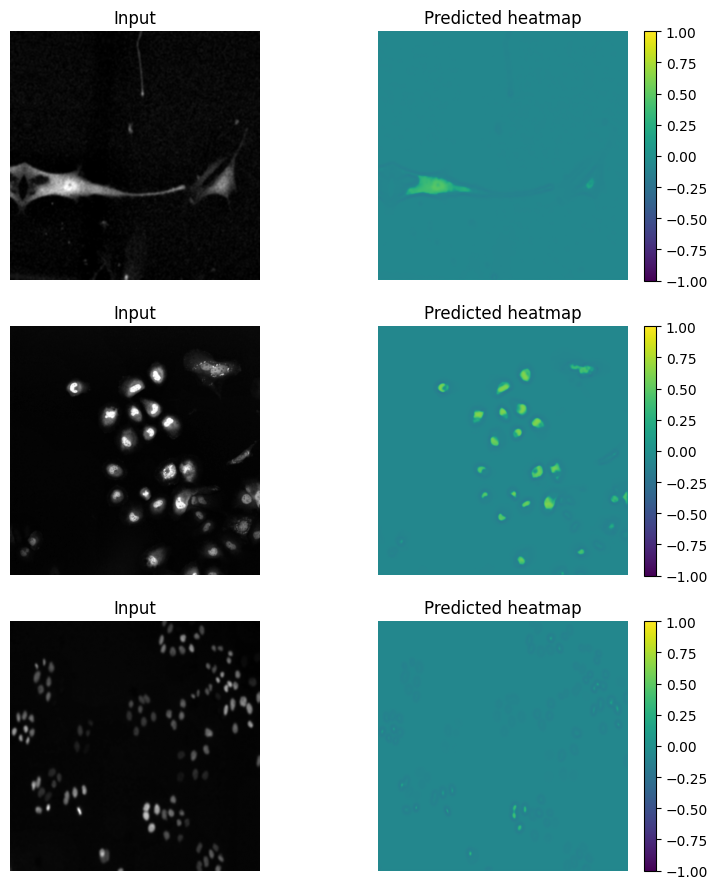

In [ ]:
# Testing and visualization
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def show_predictions(model, dataloader, device, num_samples=3):
    """Plot examples: input, interior prob, edge prob."""
    model.eval()

    examples = []
    for images, _targets in dataloader:
        images = images.to(device)
        logits = model(images)                       # [B,2,H,W]
        probs = torch.sigmoid(logits).detach().cpu()
        images_cpu = images.detach().cpu()

        for i in range(images_cpu.shape[0]):
            img_hw = images_cpu[i, 0].numpy()
            interior_hw = probs[i, 0].numpy()
            edge_hw = probs[i, 1].numpy()
            examples.append((img_hw, interior_hw, edge_hw))
            if len(examples) >= num_samples:
                break
        if len(examples) >= num_samples:
            break

    if len(examples) == 0:
        raise RuntimeError("No samples found in dataloader.")

    fig, axes = plt.subplots(len(examples), 3, figsize=(12, 3 * len(examples)))
    if len(examples) == 1:
        axes = [axes]

    for row, (img_hw, interior_hw, edge_hw) in enumerate(examples):
        ax_in, ax_int, ax_edge = axes[row]

        ax_in.imshow(img_hw, cmap="gray")
        ax_in.set_title("Input")
        ax_in.axis("off")

        im1 = ax_int.imshow(interior_hw, cmap="viridis", vmin=0.0, vmax=1.0)
        ax_int.set_title("Pred interior (p)")
        ax_int.axis("off")
        fig.colorbar(im1, ax=ax_int, fraction=0.046, pad=0.04)

        im2 = ax_edge.imshow(edge_hw, cmap="magma", vmin=0.0, vmax=1.0)
        ax_edge.set_title("Pred edge (p)")
        ax_edge.axis("off")
        fig.colorbar(im2, ax=ax_edge, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


show_predictions(model, train_loader, DEVICE, num_samples=3)